**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: --/--/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
mdl = Modeling()
varv = Variables()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Paths ----
PATH_DATA_RAW = "../../data/raw"
PATH_MODELS = "../../models"
FILE_NAME = "dataset_annealing_iacs.csv"
PROCESS = "annealing_iacs"

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of σ²_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# 2. Data

In [4]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME))
df_raw.head()

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98


In [5]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)
df_with_masks.head()

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579


In [6]:
# Keep only copper rows and the schema columns.
drop_cols = ["material", "has_Cu", "grain_size_ratio", "iacs_ratio"]
mask_cu = df_with_masks.has_Cu == True
df = df_with_masks[mask_cu].drop(columns=drop_cols)
df = df[FEATURES + [TARGET]]

assert df[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df.shape}")
df.head()

Dataset: (87, 5)


,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [7]:
predictor_a = mdl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(PATH_MODELS, PROCESS, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.28 GB / 31.57 GB (19.9%)
Disk Space Avail:   756.58 GB / 932.08 GB (81.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_a"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (105.0, 48.0, 88.01839, 11.9712)
	If 'regression' is not the correct proble

In [8]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.205490,root_mean_squared_error,0.114895,21.051823,0.000000,0.008413,2,True,10
1,ExtraTreesMSE_BAG_L1,-4.536094,root_mean_squared_error,0.042781,0.446849,0.042781,0.446849,1,True,5
2,CatBoost_BAG_L1,-4.861159,root_mean_squared_error,0.005463,51.108671,0.005463,51.108671,1,True,4
3,NeuralNetTorch_BAG_L1,-4.921912,root_mean_squared_error,0.021189,12.821432,0.021189,12.821432,1,True,8
4,RandomForestMSE_BAG_L1,-5.072580,root_mean_squared_error,0.032229,0.423637,0.032229,0.423637,1,True,3
5,NeuralNetFastAI_BAG_L1,-5.622132,root_mean_squared_error,0.050925,7.775130,0.050925,7.775130,1,True,6
6,LightGBMLarge_BAG_L1,-5.768619,root_mean_squared_error,0.015472,1.524680,0.015472,1.524680,1,True,9
7,XGBoost_BAG_L1,-6.038894,root_mean_squared_error,0.011741,0.815627,0.011741,0.815627,1,True,7
8,LightGBM_BAG_L1,-6.653741,root_mean_squared_error,0.006640,0.942294,0.006640,0.942294,1,True,2
9,LightGBMXT_BAG_L1,-6.814033,root_mean_squared_error,0.008041,0.591448,0.008041,0.591448,1,True,1


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [9]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(87,)  any NaN? False


In [10]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = mdl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 87)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [11]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = mdl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  ExtraTreesMSE_BAG_L1            0.5294
  NeuralNetFastAI_BAG_L1          0.2353
  NeuralNetTorch_BAG_L1           0.2353


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [30]:
mu_recomputed, sigma2_epist_oof = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof):.4f}")
print(f"  max    = {sigma2_epist_oof.max():.4f}")

sigma2_epist_oof stats:
  mean   = 6.3444
  median = 2.1496
  max    = 143.5851


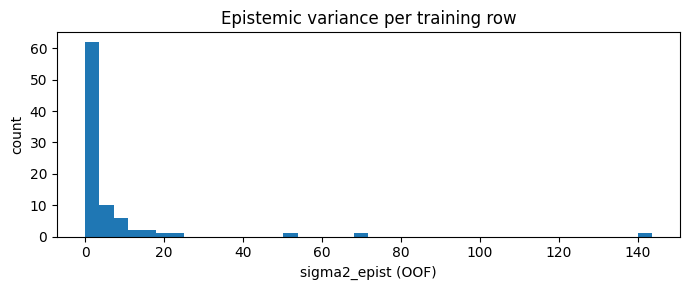

In [31]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

sigma2_epist_oof stats:
  mean   = 8.8259
  median = 3.5685
  max    = 92.4346


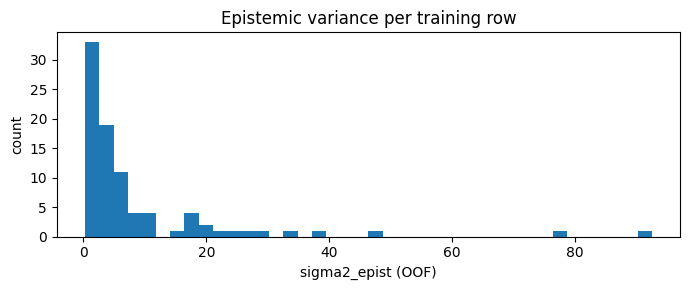

In [29]:
mu_recomputed_lin, sigma2_epist_oof_lin = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [14]:
r_tilde_sq, residuals_oof_arr, diag = mdl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 87
  n_truncated          = 41
  pct_truncated        = 47.12643678160919
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 220.49355823982455
  r_tilde_sq_mean      = 13.228926405052055
  r_tilde_sq_median    = 0.07404141117063456


# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [15]:
predictor_b = mdl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(PATH_MODELS, PROCESS, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.59 GB / 31.57 GB (17.7%)
Disk Space Avail:   749.22 GB / 932.08 GB (80.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_b"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.3958684846635725, -13.815510557964274, -5.81396, 7.77587)
	If 'regres

In [16]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.068412,root_mean_squared_error,0.029121,8.436059,0.000000,0.008932,2,True,10
1,LightGBMXT_BAG_L1,-7.068772,root_mean_squared_error,0.003069,1.001536,0.003069,1.001536,1,True,1
2,LightGBM_BAG_L1,-7.129350,root_mean_squared_error,0.000000,0.778313,0.000000,0.778313,1,True,2
3,CatBoost_BAG_L1,-7.460698,root_mean_squared_error,0.004929,1.962411,0.004929,1.962411,1,True,4
4,NeuralNetFastAI_BAG_L1,-7.502007,root_mean_squared_error,0.044386,8.245354,0.044386,8.245354,1,True,6
5,LightGBMLarge_BAG_L1,-7.574460,root_mean_squared_error,0.004129,1.410356,0.004129,1.410356,1,True,9
6,NeuralNetTorch_BAG_L1,-7.766869,root_mean_squared_error,0.026052,7.425592,0.026052,7.425592,1,True,8
7,XGBoost_BAG_L1,-7.813568,root_mean_squared_error,0.008969,0.987014,0.008969,0.987014,1,True,7
8,ExtraTreesMSE_BAG_L1,-7.950137,root_mean_squared_error,0.051100,0.527053,0.051100,0.527053,1,True,5
9,RandomForestMSE_BAG_L1,-8.124529,root_mean_squared_error,0.062821,0.496084,0.062821,0.496084,1,True,3


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [17]:
# Build the full OOF predictive distribution.
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = mdl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = mdl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
print(cal_before)

=== Calibration BEFORE recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.448276 -0.051724
1   0.80            0.735632 -0.064368
2   0.90            0.816092 -0.083908
3   0.95            0.862069 -0.087931


In [18]:
# Fit a scalar recalibration factor to pull coverage at α=0.9 to nominal.
c_opt = mdl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = mdl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
print(cal_after)

Recalibration scalar c = 1.4398

=== Calibration AFTER recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.632184  0.132184
1   0.80            0.862069  0.062069
2   0.90            0.896552 -0.003448
3   0.95            0.942529 -0.007471


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [32]:
df.head(5)

,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0


In [19]:
preds = mdl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
)
preds

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total
0,98.929506,2.309399,1.433097,7.758673,2.785440
1,99.853954,0.189104,1.433097,3.363031,1.833857
2,100.697340,3.367565,1.433097,9.952388,3.154741
3,98.192929,1.842957,1.433097,6.791679,2.606085
4,98.532241,0.326455,1.433097,3.647776,1.909915


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [20]:
artifacts_path = os.path.join(PATH_MODELS, PROCESS, "artifacts.pkl")
os.makedirs(os.path.dirname(artifacts_path), exist_ok=True)

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")

Saved to: ../../models\annealing_iacs\artifacts.pkl
